#The Deep Intuition: What is a Z-Score?
The Z-Score method assumes your data is normally distributed (a bell curve).
A Z-score simply tells you how many Standard Deviations a data point is away from the mean (average).

A Z-score of 0 means the value is exactly the average.

A Z-score of 1 means it is 1 standard deviation above average.

The Golden Rule: In a normal distribution, 99.7% of all data naturally falls between a Z-score of -3 and +3. Anything beyond 3 or -3 is incredibly rare and officially classified as an Outlier.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# let's create some dummy data with outliers
np.random.seed(42)

# Generate 1000 normal test scores (Mean: 50, Std Dev: 10)
normal_scores = np.random.normal(50, 10, 1000)

# Inject some impossible/extreme scores (Outliers)
extreme_outliers = np.array([-20, -30, -15, 120, 130, 140, 150, 125])
data = np.concatenate([normal_scores, extreme_outliers])

df = pd.DataFrame({'Score': data})

df.shape

(1008, 1)

In [5]:
# let's calculate z-score : (Value - Mean) / Standard Deviation
mean = df['Score'].mean()
std = df['Score'].std()

print(f"Mean: {mean:.2f} | Std Dev: {std:.2f}")

# Calculate the exact boundaries (Mean +/- 3 Standard deviations)
upper_limit = mean + 3 * std
lower_limit = mean - 3 * std

print(f"Lower Boundary (Z=-3): {lower_limit:.2f}")
print(f"Upper Boundary (Z=+3): {upper_limit:.2f}")

Mean: 50.39 | Std Dev: 12.05
Lower Boundary (Z=-3): 14.24
Upper Boundary (Z=+3): 86.54


In [6]:
# let's find out how many outliers we have
outliers_mask = (df['Score'] > upper_limit) | (df['Score'] < lower_limit)
print(f"Total Outliers detected: {outliers_mask.sum()}")

Total Outliers detected: 9


# There are two methods to deal with outliers:

1. Trimming (Removing): You simply delete the row. Pros: Completely removes the bad data. Cons: If you have a lot of outliers, you lose a massive chunk of your dataset.

2. Capping (Winsorization): You set a boundary. If a value crosses the boundary, you don't delete it; you just "squish" it down to equal the boundary. Pros: You keep your data volume. Cons: It artificially modifies the original numbers.

In [7]:
# let's apply trimming
# keep only the rows that are inside boundaries
df_trimmed = df[(df['Score'] <= upper_limit) & (df['Score'] >= lower_limit)]
df_trimmed.shape

(999, 1)

In [8]:
# let's apply capping
df_capped = df.copy()

df_capped['Score'] = np.where(
    df_capped['Score'] > upper_limit, upper_limit,
    np.where(df_capped['Score'] < lower_limit, lower_limit, df_capped['Score']
    )
)

df_capped.shape

(1008, 1)

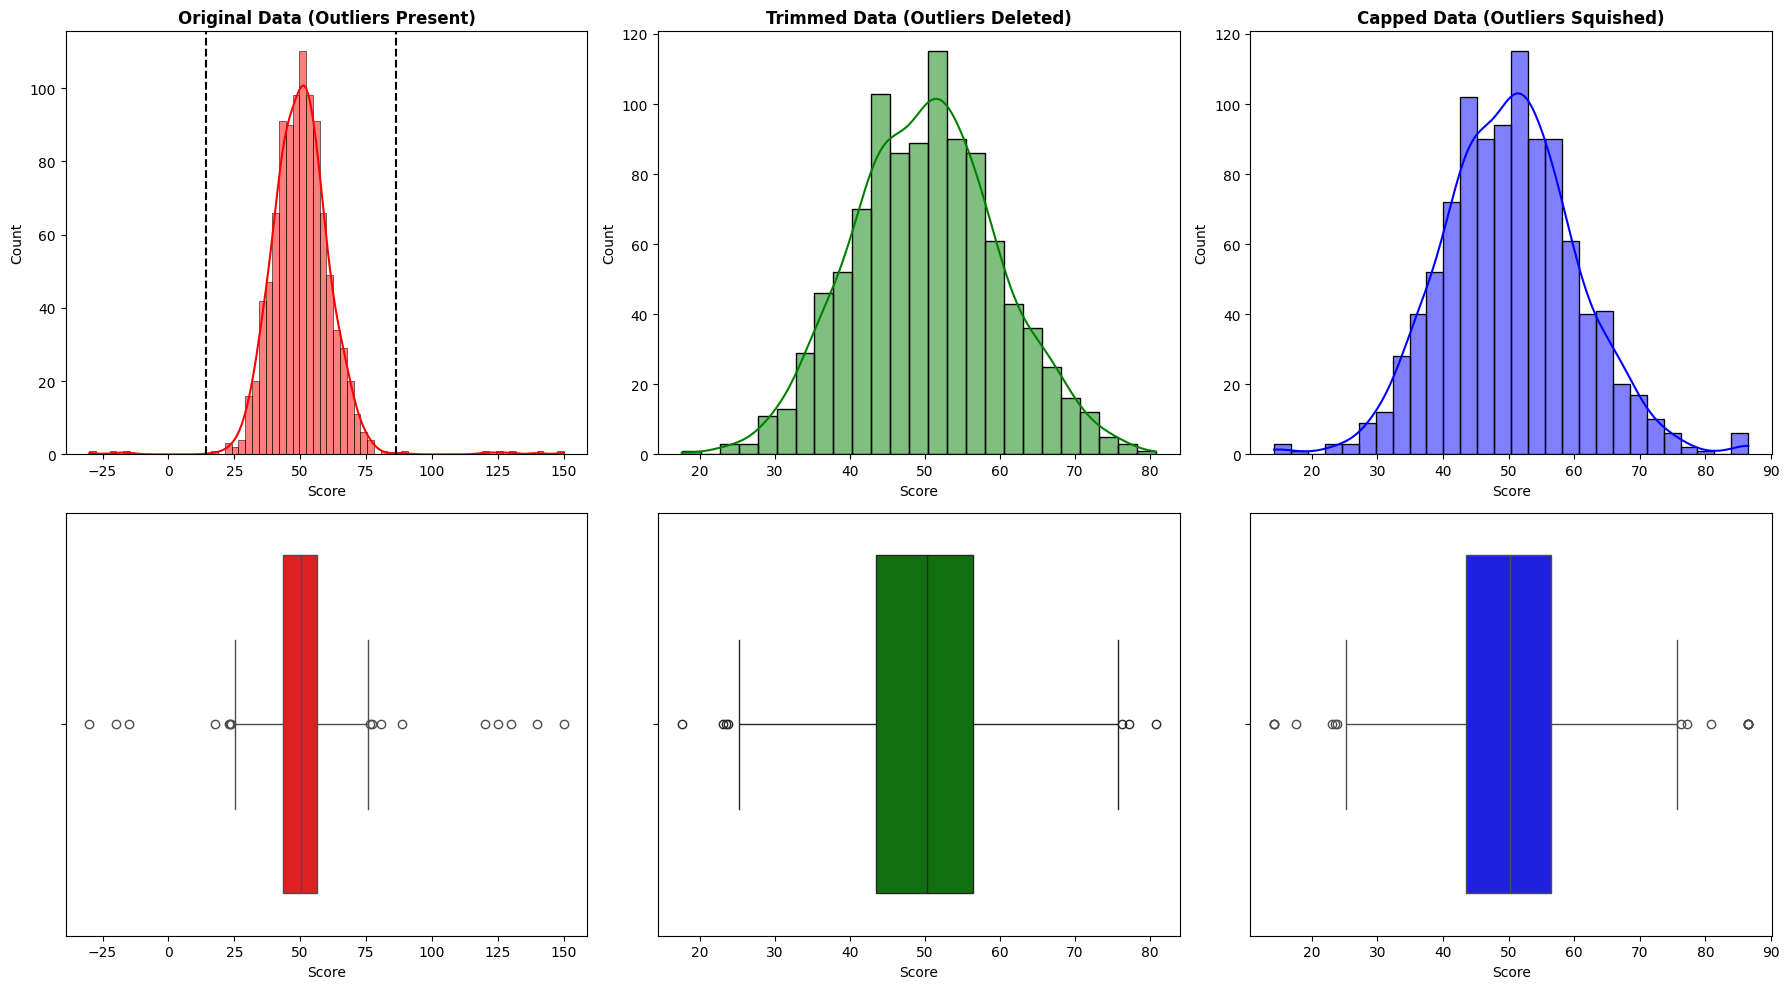


Notice the Capped Boxplot (Blue): The outliers weren't deleted, they were dragged exactly to the 'whisker' boundaries!


In [9]:
# 5. VISUALIZE THE PROOF
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: Distribution (KDE) Plots
sns.histplot(df['Score'], kde=True, ax=axes[0, 0], color='red')
axes[0, 0].set_title('Original Data (Outliers Present)', fontweight='bold')
axes[0, 0].axvline(upper_limit, color='black', linestyle='--')
axes[0, 0].axvline(lower_limit, color='black', linestyle='--')

sns.histplot(df_trimmed['Score'], kde=True, ax=axes[0, 1], color='green')
axes[0, 1].set_title('Trimmed Data (Outliers Deleted)', fontweight='bold')

sns.histplot(df_capped['Score'], kde=True, ax=axes[0, 2], color='blue')
axes[0, 2].set_title('Capped Data (Outliers Squished)', fontweight='bold')

# Row 2: Boxplots (The ultimate outlier visualizer)
sns.boxplot(x=df['Score'], ax=axes[1, 0], color='red')
sns.boxplot(x=df_trimmed['Score'], ax=axes[1, 1], color='green')
sns.boxplot(x=df_capped['Score'], ax=axes[1, 2], color='blue')

plt.tight_layout()
plt.show()

print("\nNotice the Capped Boxplot (Blue): The outliers weren't deleted, they were dragged exactly to the 'whisker' boundaries!")

- The Original Data (Red): The KDE curve stretches out super far to the left and right, and the boxplot shows those isolated dots (outliers) way past the main box.

-  The Trimmed Data (Green): Perfectly clean. The dots are gone. But remember, we permanently lost rows of data doing this.

- The Capped Data (Blue): Look at the KDE curve—there is a sudden "spike" at the extreme left and right edges. That is because we took all those crazy -30 and 150 scores and squished them perfectly onto the lower_limit and upper_limit boundaries!